<a href="https://colab.research.google.com/github/mayaluheda/garminDataAnalysis/blob/main/garminData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
# load the JSON file into a pandas DataFrame
# our data is downloaded via garmin
df = pd.read_json('/content/summarizedActivities.json')

# let's look at the first few rows
display(df.head())

,summarizedActivitiesExport
0,"[{'activityId': 23881533883, 'uuidMsb': -33200..."


In [ ]:
#'summarizedActivitiesExport' column which contains a list of dictionaries
activities_df = pd.json_normalize(df['summarizedActivitiesExport'].explode())

# display the first few rows of the new DataFrame to verify the structure
display(activities_df.head())

,activityId,uuidMsb,uuidLsb,name,activityType,userProfileId,timeZoneId,beginTimestamp,eventTypeId,rule,...,powerTimeInZone_7,workoutId,matchedCuratedCourseId,description,surfaceInterval,avgVerticalSpeed,floorsClimbed,floorsDescended,jumpCount,poolLength
0,23881533883,-3320022720066338150,-8372430646435352008,Yoga,yoga,123705292,149,1786060009000,9,subscribers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23868136353,3529275490336066895,-6119260630349733233,New York Track Running,track_running,123705292,149,1785969014000,9,subscribers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23861503057,-4783367034164657114,-5895384909711257433,HIIT,hiit,123705292,149,1785882528000,9,subscribers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,23843032989,3206082880894224996,-6228432858090717220,New York Running,running,123705292,149,1785794283000,9,subscribers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,23830767554,-5454249099652938134,-4819374563559545092,New York Running,running,123705292,149,1785705888000,9,subscribers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# for each unique activity, how many occurrences?
activity_counts = activities_df['activityType'].value_counts()

print("Activity Type Distribution:")
print(activity_counts)

# convert duration from milliseconds to hours
activities_df['duration_hours'] = activities_df['duration'] / (1000 * 60 * 60)

# convert distance from centimeters to miles
activities_df['distance_miles'] = activities_df['distance'] / 160934

# calculate total duration of all activities
total_duration_hours = activities_df['duration_hours'].sum()
print(f"\nTotal Duration of All Activities: {total_duration_hours:.2f} hours")

# calculate average duration per activity type
avg_duration_per_type = activities_df.groupby('activityType')['duration_hours'].mean().sort_values(ascending=False)
print("\nAverage Duration per Activity Type (hours):")
print(avg_duration_per_type)

Activity Type Distribution:
activityType
running                230
hiit                    98
cycling                 63
yoga                    25
hiking                  22
strength_training       22
lap_swimming            21
walking                 17
treadmill_running       14
indoor_cardio           10
indoor_cycling          10
breathwork               9
track_running            5
open_water_swimming      4
trail_running            2
pickleball               1
assistance               1
Name: count, dtype: int64

Total Duration of All Activities: 482.68 hours

Average Duration per Activity Type (hours):
activityType
hiking                 1.788767
hiit                   1.372964
lap_swimming           1.352415
trail_running          1.012056
pickleball             0.894966
yoga                   0.848127
cycling                0.722214
walking                0.714167
running                0.707824
indoor_cardio          0.664157
open_water_swimming    0.641391
indoor_cycling  

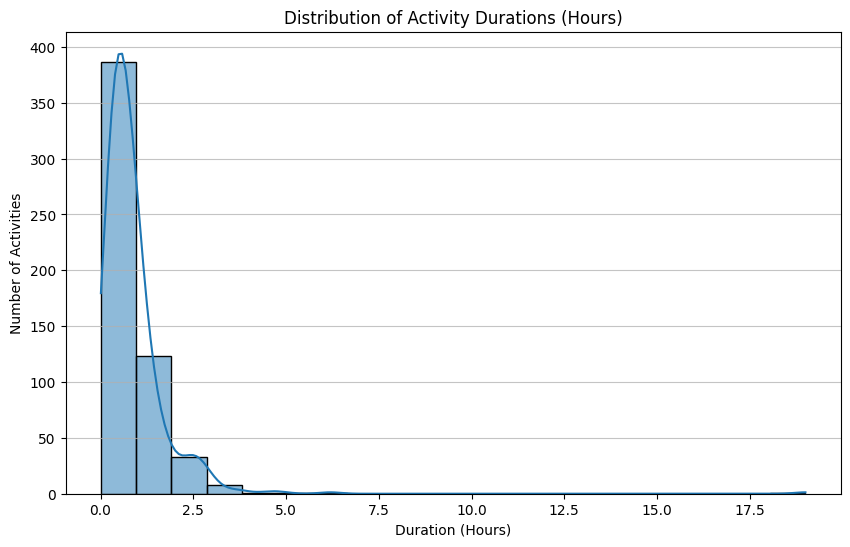

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(activities_df['duration_hours'], bins=20, kde=True)
plt.title('Distribution of Activity Durations (Hours)')
plt.xlabel('Duration (Hours)')
plt.ylabel('Number of Activities')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Average Distance Covered per Activity Type

In [ ]:
avg_distance_per_type = activities_df.groupby('activityType')['distance_miles'].mean().sort_values(ascending=False)
display(avg_distance_per_type)

,distance_miles
activityType,
cycling,6.296822
trail_running,5.186017
running,4.445509
indoor_cycling,2.813871
hiking,2.644078
track_running,1.830564
walking,1.403206
treadmill_running,1.227113
open_water_swimming,0.414364


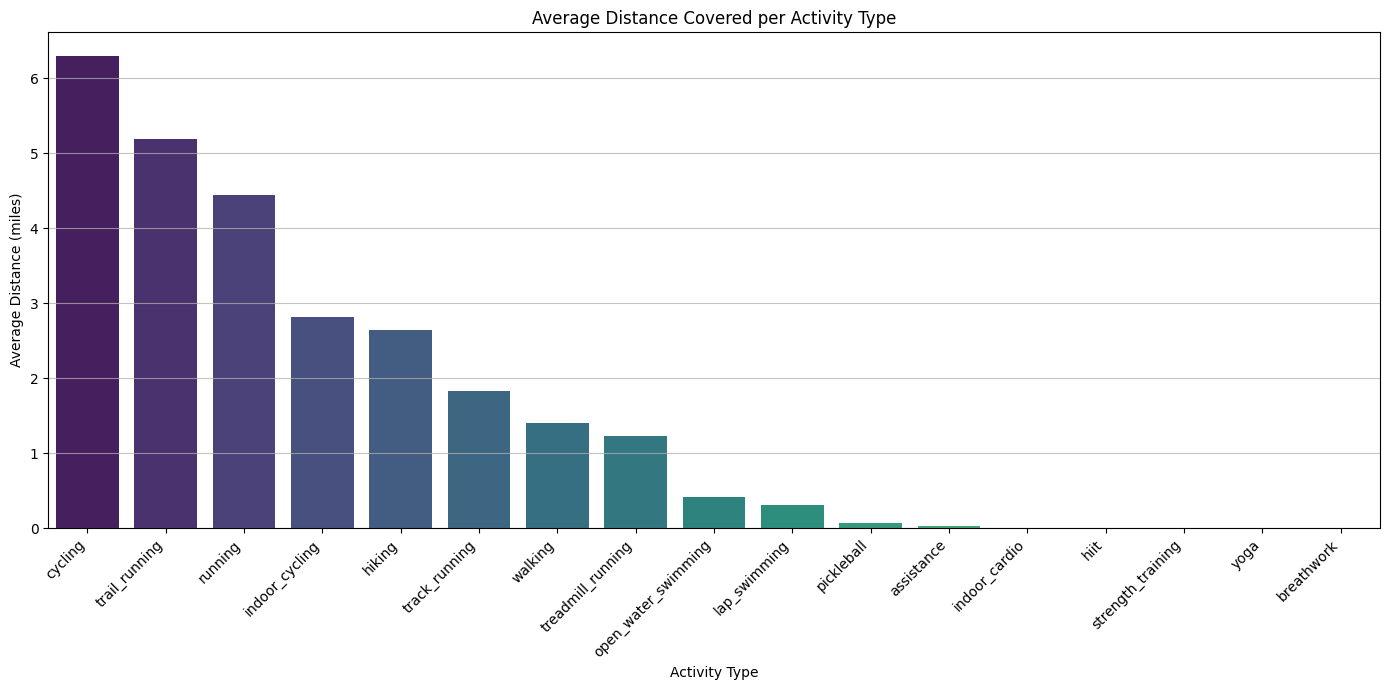

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x=avg_distance_per_type.index, y=avg_distance_per_type.values, palette='viridis', hue=avg_distance_per_type.index, legend=False)
plt.title('Average Distance Covered per Activity Type')
plt.xlabel('Activity Type')
plt.ylabel('Average Distance (miles)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [ ]:
# convert from milliseconds to seconds
activities_df['duration_seconds'] = activities_df['duration'] / 1000

# calculate speed in miles per hour (mph)
activities_df['speed_mph'] = activities_df['distance_miles'] / activities_df['duration_hours']

# calculate the average speed per activity type
avg_speed_per_type = activities_df.groupby('activityType')['speed_mph'].mean().sort_values(ascending=False)

display(avg_speed_per_type)

,speed_mph
activityType,
cycling,8.804401
track_running,8.759689
running,6.348452
indoor_cycling,5.610812
trail_running,5.395616
treadmill_running,3.506592
assistance,3.289517
walking,2.083423
hiking,1.121554


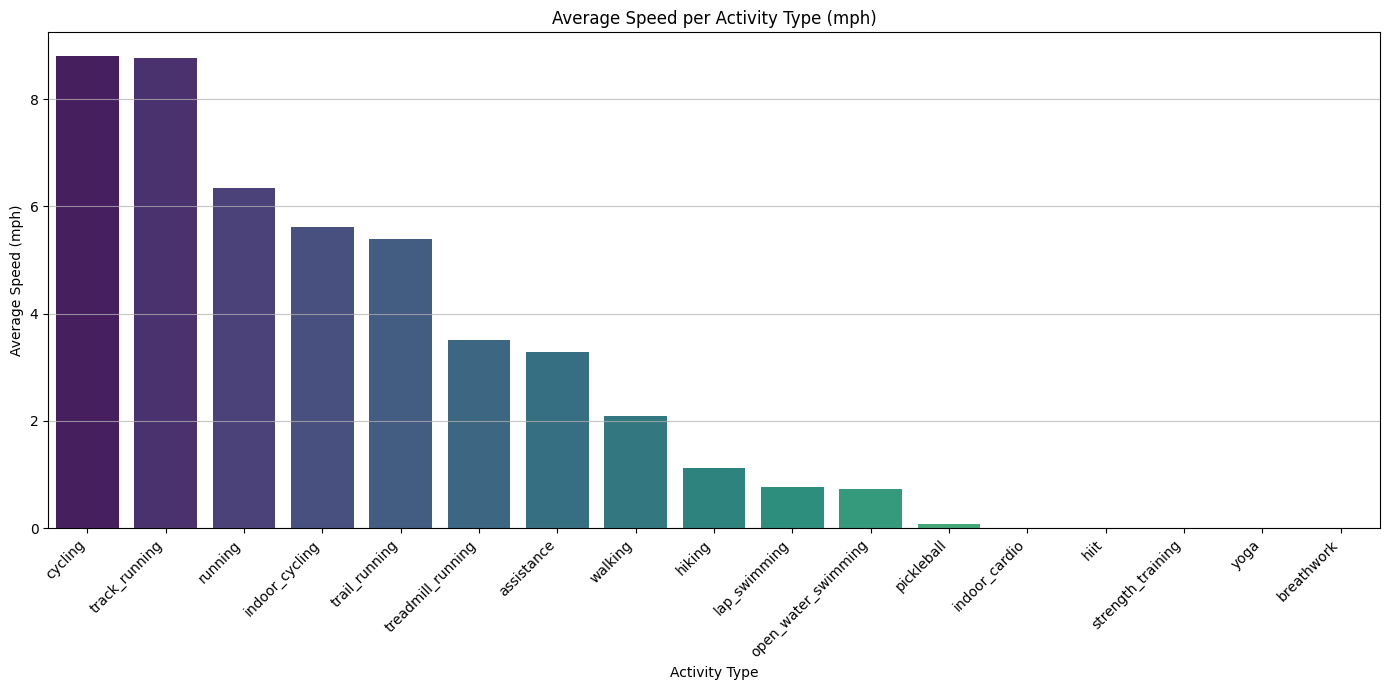

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x=avg_speed_per_type.index, y=avg_speed_per_type.values, palette='viridis', hue=avg_speed_per_type.index, legend=False)
plt.title('Average Speed per Activity Type (mph)')
plt.xlabel('Activity Type')
plt.ylabel('Average Speed (mph)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Summary Statistics for Speed (km/h) per Activity Type

In [ ]:
speed_summary_stats = activities_df.groupby('activityType')['speed_mph'].describe()
display(speed_summary_stats)

,count,mean,std,min,25%,50%,75%,max
activityType,,,,,,,,
assistance,1.0,3.289517,NaN,3.289517,3.289517,3.289517,3.289517,3.289517
breathwork,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cycling,63.0,8.804401,1.695155,4.476235,7.954116,9.197478,9.941211,12.221904
hiit,98.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hiking,22.0,1.121554,0.960179,0.000000,0.019525,1.301819,1.860353,2.714263
indoor_cardio,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
indoor_cycling,10.0,5.610812,7.515481,0.000000,0.000000,0.000000,12.564274,16.997800
lap_swimming,21.0,0.768695,0.419457,0.006728,0.480629,0.780352,1.073294,1.463713
open_water_swimming,4.0,0.730472,0.270496,0.443232,0.550787,0.712245,0.891930,1.054167


### Total Calories Burned per Activity Type

In [ ]:
total_calories_per_type = activities_df.groupby('activityType')['calories'].sum().sort_values(ascending=False)
display(total_calories_per_type)

,calories
activityType,
running,476694.38538
hiit,125926.86108
cycling,82065.73172
hiking,58894.92112
lap_swimming,47984.10904
strength_training,14753.06042
yoga,13156.66280
indoor_cycling,12670.62048
walking,12201.33824


### Average Calories Burned per Activity Type

/tmp/ipykernel_483/3596211427.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_calories_per_type.index, y=avg_calories_per_type.values, palette='viridis')


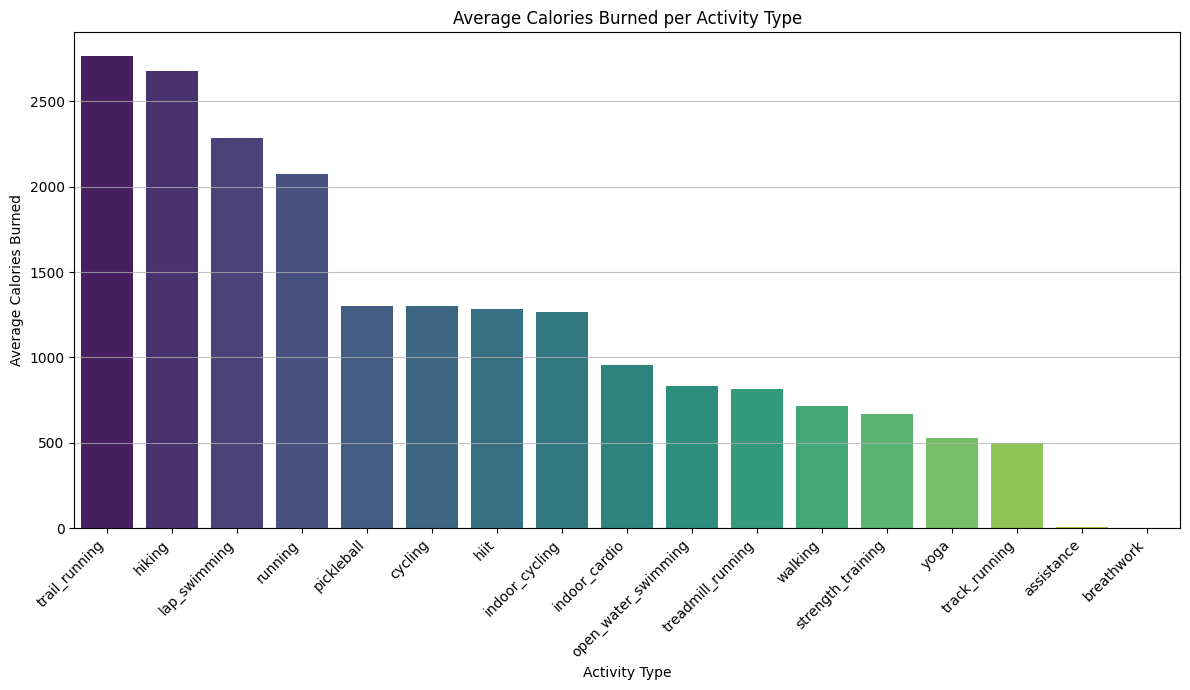

In [ ]:
# Calculate average calories burned per activity type
avg_calories_per_type = activities_df.groupby('activityType')['calories'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_calories_per_type.index, y=avg_calories_per_type.values, palette='viridis')
plt.title('Average Calories Burned per Activity Type')
plt.xlabel('Activity Type')
plt.ylabel('Average Calories Burned')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Correlation between Activity Duration and Calories Burned

In [ ]:
correlation = activities_df['duration_hours'].corr(activities_df['calories'])
print(f"Pearson correlation between activity duration and calories burned: {correlation:.2f}")

Pearson correlation between activity duration and calories burned: 0.86


In [ ]:
running_activities = activities_df[activities_df['activityType'] == 'running']

avg_running_duration = running_activities['duration_hours'].mean()
avg_running_speed = running_activities['speed_mph'].mean() # Use speed_mph

print(f"Average duration for 'running' activities: {avg_running_duration:.2f} hours")
print(f"Average speed for 'running' activities: {avg_running_speed:.2f} mph")

Average duration for 'running' activities: 0.71 hours
Average speed for 'running' activities: 6.35 mph


In [ ]:
# Convert 'beginTimestamp' from milliseconds to datetime objects
activities_df['start_time'] = pd.to_datetime(activities_df['beginTimestamp'], unit='ms')

# Filter for running activities and sort by start_time
running_activities_over_time = activities_df[activities_df['activityType'] == 'running'].sort_values('start_time')

# Calculate a rolling average for speed_mph (e.g., a 7-day rolling average)
running_activities_over_time['speed_mph_rolling_avg'] = running_activities_over_time['speed_mph'].rolling(window=7, min_periods=1).mean()

### Distribution of Running Speeds

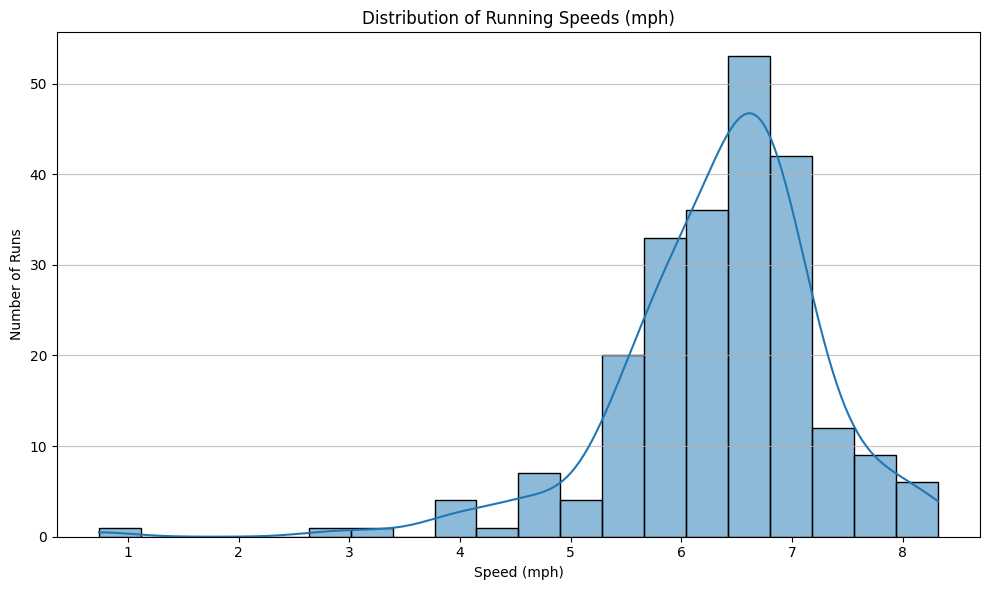

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(running_activities['speed_mph'], bins=20, kde=True) # Use speed_mph
plt.title('Distribution of Running Speeds (mph)')
plt.xlabel('Speed (mph)')
plt.ylabel('Number of Runs')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [ ]:
# Convert average running speed from mph to min/mile
pace_min_per_mile = 60 / avg_running_speed

print(f"Average pace for 'running' activities: {pace_min_per_mile:.2f} minutes per mile")

Average pace for 'running' activities: 9.45 minutes per mile


### Monthly Running Volume (Total Distance) and Frequency

In [ ]:
# Ensure 'start_time' is datetime (already done in previous steps, but good to ensure)
activities_df['start_time'] = pd.to_datetime(activities_df['beginTimestamp'], unit='ms')

# Filter for running activities
running_activities_monthly = activities_df[activities_df['activityType'] == 'running'].copy()

# Extract month from start_time
running_activities_monthly['month'] = running_activities_monthly['start_time'].dt.to_period('M')

# Group by month and calculate average speed and distance
# Use speed_mph and distance_miles
monthly_summary = running_activities_monthly.groupby('month')[['speed_mph', 'distance_miles']].mean()

print("Average Running Speed and Distance by Month:")
display(monthly_summary.sort_index())

Average Running Speed and Distance by Month:


,speed_mph,distance_miles
month,,
2024-07,5.598697,2.958652
2024-08,5.898835,4.958573
2024-09,5.707509,3.634956
2024-10,5.755577,4.629161
2024-11,6.639141,5.619308
2024-12,6.157974,5.835246
2025-01,6.228706,3.116820
2025-02,6.573874,5.507164
2025-03,6.697501,5.539786


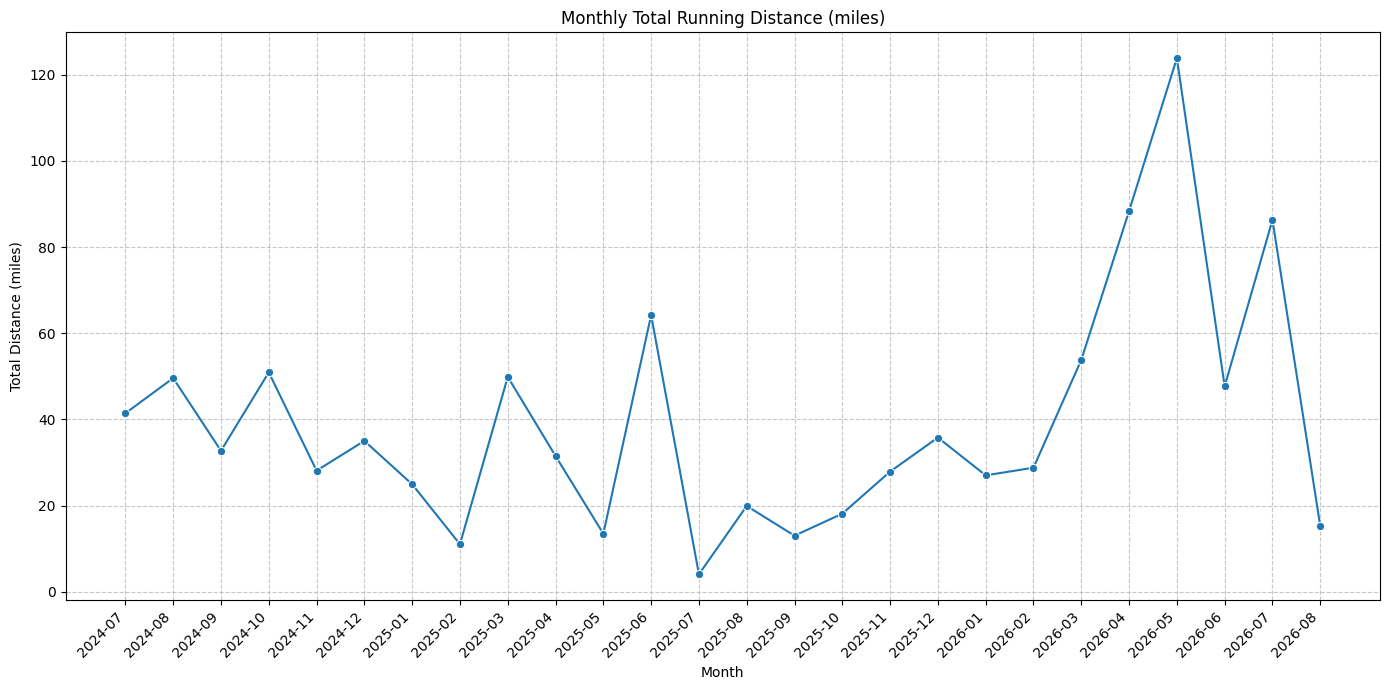

In [ ]:
# Calculate total monthly running distance
# Assuming `running_activities_monthly` will be defined with `distance_miles` from a previous cell.
monthly_total_distance = running_activities_monthly.groupby('month')['distance_miles'].sum().reset_index()
monthly_total_distance['month'] = monthly_total_distance['month'].astype(str)

plt.figure(figsize=(14, 7))
sns.lineplot(x='month', y='distance_miles', data=monthly_total_distance, marker='o')
plt.title('Monthly Total Running Distance (miles)')
plt.xlabel('Month')
plt.ylabel('Total Distance (miles)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()